# Fase 2 — Comprensión y Análisis Exploratorio de los Datos (EDA)
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas
**Curso:** Algoritmos y Programación III — Semestre 2026-1

---
EDA exhaustiva sobre el **dataset combinado real**: Kaggle (`data/external`) +
recolección propia (`data/raw`), escaneando carpetas.

| Sección | Contenido |
|---|---|
| 1 | Inventario (fuente × calidad × fruta) |
| 2 | Distribución de clases, desbalanceo, anomalía Pomegranate, **label noise** |
| 3 | **Discordancia espacial** de Mixed (boxplots, KDE, Kolmogórov–Smirnov, ECDF) |
| 4 | Propiedades visuales (brillo/contraste/saturación) y resolución |
| 5 | **Solapamiento distributivo** Mixed (HSV+LBP PCA/t-SNE, Jensen–Shannon, Bhattacharyya) |
| 6 | Espacio de color RGB por clase |
| 7 | Ejemplos por clase |
| 8 | Tests estadísticos (Kruskal–Wallis) |
| 9 | Propio vs Kaggle (Mann–Whitney U) |
| 10 | Conclusiones decisiones para Fase 3 |

## 0. Configuración del entorno

In [1]:
import sys, pathlib, random, math
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import ks_2samp, kruskal, mannwhitneyu
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
sns.set_theme(style="whitegrid")
from src.config import EXTERNAL_DIR, RAW_DIR, FIGURES_DIR, QUALITY_CLASSES, SEED
random.seed(SEED); np.random.seed(SEED)
QPAL = {"Premium":"#2ecc71","Estándar":"#f39c12","Descarte":"#e74c3c","Mixed":"#9b59b6"}
FPAL = {"Good":"#2ecc71","Regular":"#f39c12","Bad":"#e74c3c","Mixed":"#9b59b6"}
print("Repo:", ROOT)

Repo: /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier


## 1. Inventario del dataset combinado
Escaneamos ambas fuentes (incluida Mixed, que se **analiza** pero no es clase de
entrenamiento). Cada imagen: ruta, `folder` (Good/Regular/Bad/Mixed), calidad,
fruta y fuente (Kaggle/Propio).

In [2]:
IMG_EXTS={'.jpg','.jpeg','.png','.webp','.bmp'}
FOLDER_Q={'Good':'Premium','Regular':'Estándar','Bad':'Descarte','Mixed':'Mixed'}
def scan(base, source):
    rows=[]
    if not base.exists(): return rows
    for qdir in sorted(base.iterdir()):
        if not qdir.is_dir(): continue
        key='Mixed' if qdir.name.startswith('Mixed') else qdir.name.split(' ')[0]
        q=FOLDER_Q.get(key)
        if q is None: continue
        for fdir in sorted(qdir.iterdir()):
            if not fdir.is_dir(): continue
            fruit=fdir.name.split('_')[0]
            for im in fdir.iterdir():
                if im.suffix.lower() in IMG_EXTS:
                    rows.append({'path':str(im),'folder':key,'quality':q,'fruit':fruit,'source':source})
    return rows
df = pd.DataFrame(scan(EXTERNAL_DIR,'Kaggle')+scan(RAW_DIR,'Propio'))
print('═'*60)
print(f"  Total imágenes      : {len(df):,}")
print(f"  Kaggle / Propio     : {(df.source=='Kaggle').sum():,} / {(df.source=='Propio').sum():,}")
print(f"  Tipos de fruta      : {df.fruit.nunique()}  -> {sorted(df.fruit.unique())}")
print(f"  Carpetas de origen  : {sorted(df.folder.unique())}")
print('═'*60)
display(df.head(6))

════════════════════════════════════════════════════════════
  Total imágenes      : 26,385
  Kaggle / Propio     : 19,526 / 6,859
  Tipos de fruta      : 7  -> ['Apple', 'Banana', 'Guava', 'Lemon', 'Lime', 'Orange', 'Pomegranate']
  Carpetas de origen  : ['Bad', 'Good', 'Mixed', 'Regular']
════════════════════════════════════════════════════════════


,path,folder,quality,fruit,source
0,/home/juan-pablo/Documents/SEMESTRE7/APO3/PF/f...,Bad,Descarte,Apple,Kaggle
1,/home/juan-pablo/Documents/SEMESTRE7/APO3/PF/f...,Bad,Descarte,Apple,Kaggle
2,/home/juan-pablo/Documents/SEMESTRE7/APO3/PF/f...,Bad,Descarte,Apple,Kaggle
3,/home/juan-pablo/Documents/SEMESTRE7/APO3/PF/f...,Bad,Descarte,Apple,Kaggle
4,/home/juan-pablo/Documents/SEMESTRE7/APO3/PF/f...,Bad,Descarte,Apple,Kaggle
5,/home/juan-pablo/Documents/SEMESTRE7/APO3/PF/f...,Bad,Descarte,Apple,Kaggle


## 2. Distribución de clases de calidad
### 2.1 Conteos y ratio de desbalance (3 clases de entrenamiento; Mixed aparte)

   Clase     N     %  Ratio vs mín
 Premium 11797 46.61          2.08
Estándar  5680 22.44          1.00
Descarte  7834 30.95          1.38

Imbalance Ratio: 2.08x → MODERADO


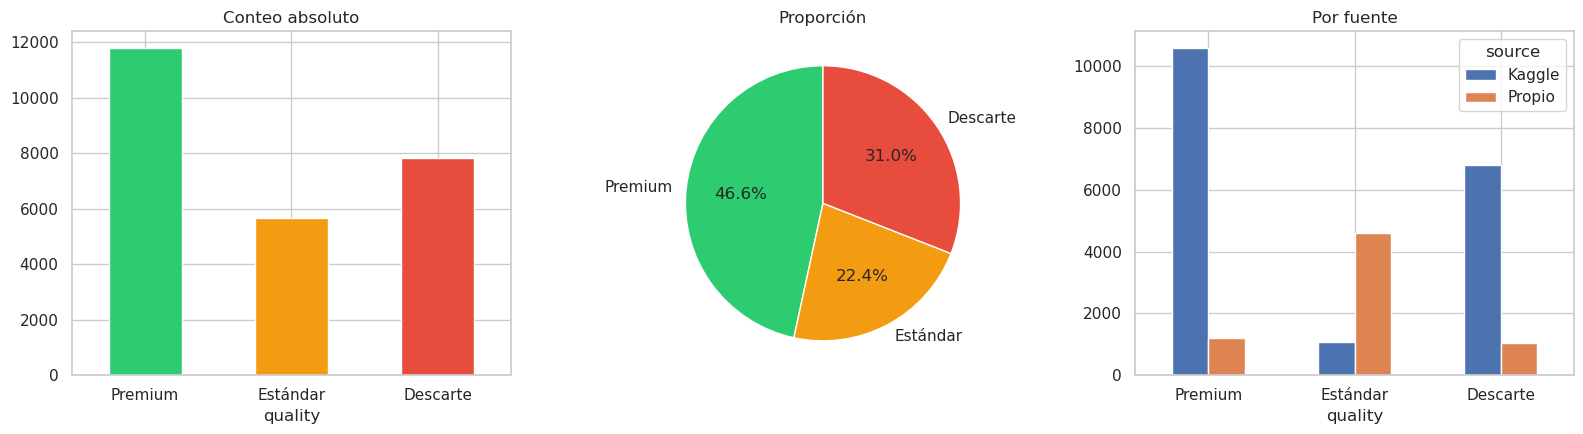

In [3]:
train_q = df[df['quality']!='Mixed']
cc = train_q['quality'].value_counts().reindex(QUALITY_CLASSES)
pct = (cc/cc.sum()*100).round(2)
summary = pd.DataFrame({'Clase':cc.index,'N':cc.values,'%':pct.values,
                        'Ratio vs mín':(cc.values/cc.min()).round(2)})
print(summary.to_string(index=False))
ir = cc.max()/cc.min()
print(f"\nImbalance Ratio: {ir:.2f}x", "→ CRÍTICO" if ir>5 else "→ MODERADO" if ir>2 else "→ aceptable")
fig,ax=plt.subplots(1,3,figsize=(16,4.5))
cc.plot.bar(ax=ax[0], color=[QPAL[c] for c in cc.index]); ax[0].set_title("Conteo absoluto"); ax[0].tick_params(axis='x',rotation=0)
ax[1].pie(cc.values, labels=cc.index, colors=[QPAL[c] for c in cc.index], autopct='%1.1f%%', startangle=90); ax[1].set_title("Proporción")
pd.crosstab(train_q['quality'],train_q['source']).reindex(QUALITY_CLASSES).plot.bar(ax=ax[2]); ax[2].set_title("Por fuente"); ax[2].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_distribucion.pdf", bbox_inches="tight"); plt.show()

### 2.2 Distribución por fruta × clase (heatmap)

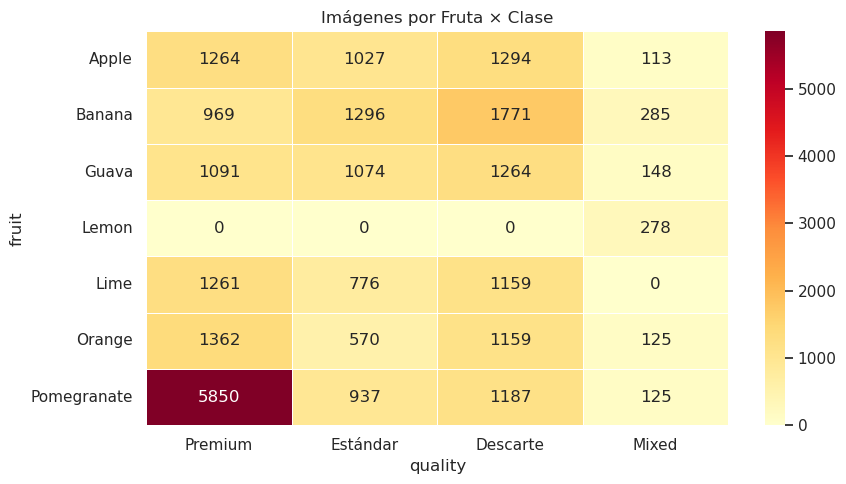

quality      Premium  Estándar  Descarte  Mixed
fruit                                          
Apple           1264      1027      1294    113
Banana           969      1296      1771    285
Guava           1091      1074      1264    148
Lemon              0         0         0    278
Lime            1261       776      1159      0
Orange          1362       570      1159    125
Pomegranate     5850       937      1187    125


In [4]:
pivot = pd.crosstab(df['fruit'], df['quality']).reindex(columns=[c for c in ['Premium','Estándar','Descarte','Mixed'] if c in df['quality'].unique()])
fig,ax=plt.subplots(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5, linecolor='white', ax=ax)
ax.set_title("Imágenes por Fruta × Clase"); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_heatmap.pdf", bbox_inches="tight"); plt.show()
print(pivot.to_string())

### 2.3 Anomalía: Pomegranate_Good sobreinflada
Verificamos el sesgo de una fruta dentro de Premium (hallazgo que motiva el cap por fruta×clase en Fase 3).

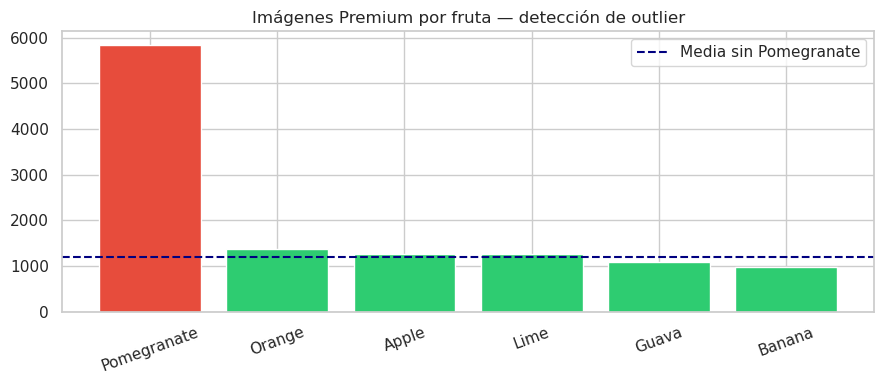

{'Pomegranate': 5850, 'Orange': 1362, 'Apple': 1264, 'Lime': 1261, 'Guava': 1091, 'Banana': 969}


In [5]:
prem = df[df.quality=='Premium'].groupby('fruit').size().sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(9,4))
cols=['#e74c3c' if v>prem.median()*2 else '#2ecc71' for v in prem.values]
ax.bar(prem.index, prem.values, color=cols, edgecolor='white')
ax.axhline(prem.drop('Pomegranate',errors='ignore').mean(), color='navy', ls='--', label='Media sin Pomegranate')
ax.set_title("Imágenes Premium por fruta — detección de outlier"); ax.legend(); ax.tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_pomegranate.pdf", bbox_inches="tight"); plt.show()
print(prem.to_dict())

### 2.4 Evidencia de *label noise* y taxonomía de 3 clases
Inspección visual de la clase Premium (buscar fondos no uniformes, racimos, manos)
y muestra de las 3 clases finales. La clase **Estándar** se nutre de las carpetas
*Regular* reales (no de Mixed), lo que reduce el ruido de etiqueta.

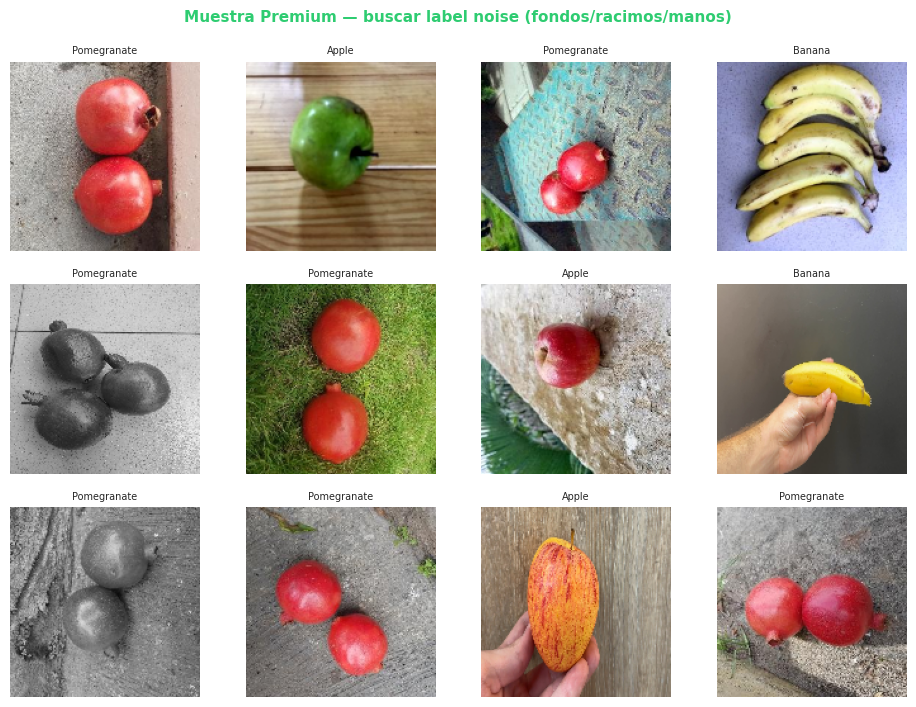

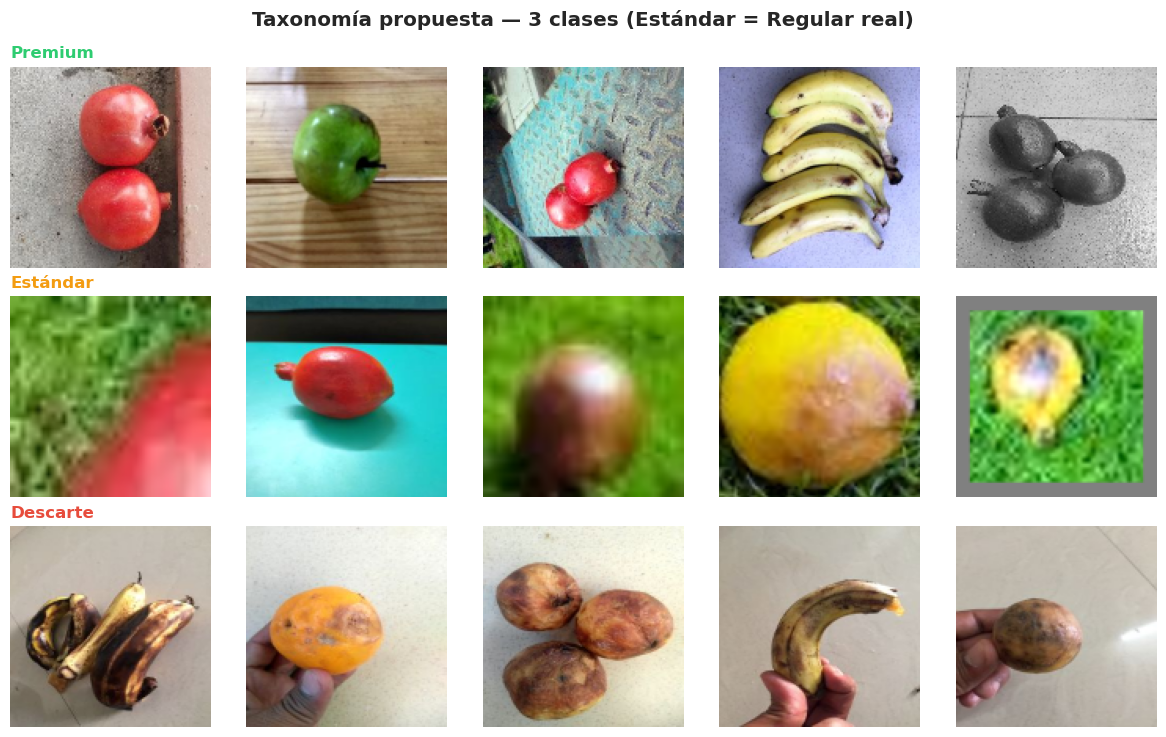

In [6]:
def grid(sub, title, fname, color='black', n=12, ncols=4):
    sub = sub.sample(min(n,len(sub)), random_state=SEED)
    nrows=math.ceil(len(sub)/ncols)
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*2.4,nrows*2.4)); axes=np.array(axes).reshape(-1)
    fig.suptitle(title, fontsize=11, fontweight='bold', color=color)
    for ax,(_,r) in zip(axes, sub.iterrows()):
        im=cv2.imread(r['path']); ax.axis('off')
        if im is not None:
            ax.imshow(cv2.cvtColor(cv2.resize(im,(150,150)),cv2.COLOR_BGR2RGB)); ax.set_title(r['fruit'],fontsize=7)
    for ax in axes[len(sub):]: ax.axis('off')
    plt.tight_layout(); plt.savefig(FIGURES_DIR/fname, bbox_inches="tight"); plt.show()
grid(df[df.quality=='Premium'], "Muestra Premium — buscar label noise (fondos/racimos/manos)", "fase2_labelnoise_premium.pdf", QPAL['Premium'], n=12)
# Taxonomía 3 clases reales
fig,axes=plt.subplots(3,5,figsize=(12,7.5))
for r,q in enumerate(QUALITY_CLASSES):
    s=df[df.quality==q].sample(5,random_state=SEED)
    for c,(_,row) in enumerate(s.iterrows()):
        im=cv2.imread(row['path']); axes[r,c].axis('off')
        if im is not None: axes[r,c].imshow(cv2.cvtColor(cv2.resize(im,(128,128)),cv2.COLOR_BGR2RGB))
    axes[r,0].set_title(q, loc='left', color=QPAL[q], fontweight='bold')
fig.suptitle("Taxonomía propuesta — 3 clases (Estándar = Regular real)", fontweight='bold')
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_taxonomia.pdf", bbox_inches="tight"); plt.show()

## 3. Análisis espacial de discordancia (Mixed)
La carpeta **Mixed** tiene varias frutas por foto otra resolución/aspecto.
Lo demostramos con boxplots, KDE y el test de **Kolmogórov–Smirnov**.

/tmp/ipykernel_1101402/594910256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dim_df,x='folder',y=m,order=order,palette=FPAL,ax=a,width=.5); a.set_title(lab); a.tick_params(axis='x',rotation=0)
/tmp/ipykernel_1101402/594910256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dim_df,x='folder',y=m,order=order,palette=FPAL,ax=a,width=.5); a.set_title(lab); a.tick_params(axis='x',rotation=0)
/tmp/ipykernel_1101402/594910256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dim_df,x='folder',y=m,order=order,palette=

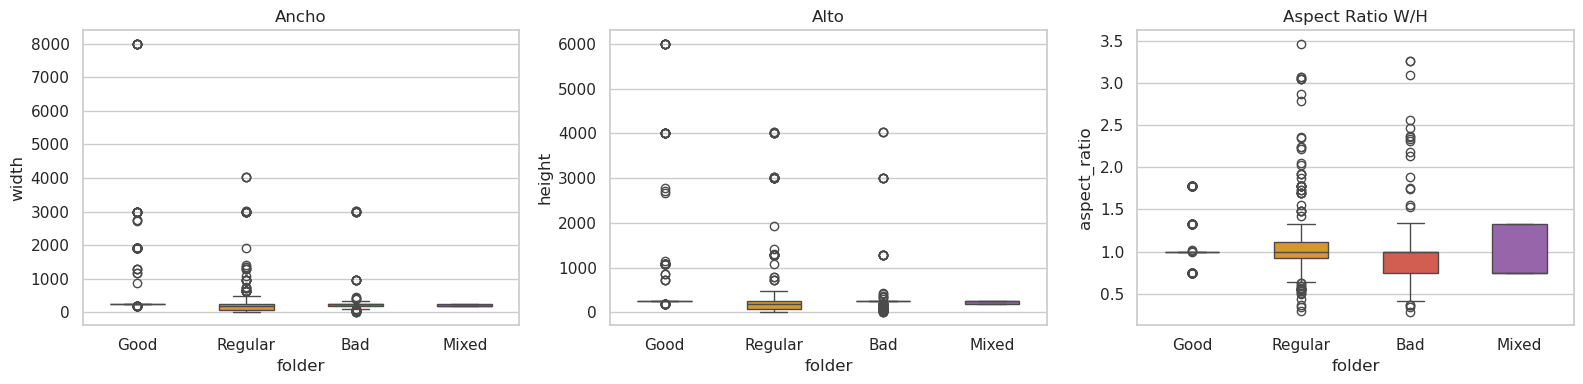

In [7]:
def dims(paths):
    out=[]
    for p in paths:
        im=cv2.imread(p)
        if im is not None:
            h,w=im.shape[:2]; out.append((w,h,w/h))
    return np.array(out)
def samp(folders,n=400):
    g=df[df['folder'].isin(folders)]
    return g.sample(min(n,len(g)),random_state=SEED)['path'].tolist()
dim_rows=[]
for f in ['Good','Regular','Bad','Mixed']:
    for (w,h,ar) in dims(samp([f])):
        dim_rows.append({'folder':f,'width':w,'height':h,'aspect_ratio':ar})
dim_df=pd.DataFrame(dim_rows)
order=[f for f in ['Good','Regular','Bad','Mixed'] if f in dim_df.folder.unique()]
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,(m,lab) in zip(ax,[('width','Ancho'),('height','Alto'),('aspect_ratio','Aspect Ratio W/H')]):
    sns.boxplot(data=dim_df,x='folder',y=m,order=order,palette=FPAL,ax=a,width=.5); a.set_title(lab); a.tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_dim_boxplots.pdf", bbox_inches="tight"); plt.show()

### 3.1 KDE de resolución por carpeta

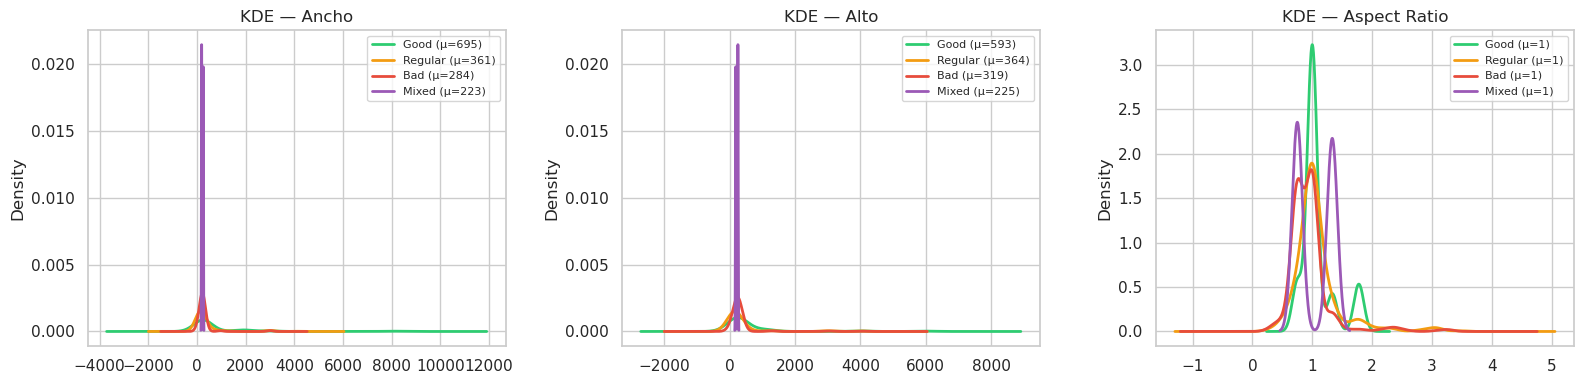

In [8]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,(m,lab) in zip(ax,[('width','Ancho'),('height','Alto'),('aspect_ratio','Aspect Ratio')]):
    for f in order:
        g=dim_df[dim_df.folder==f][m]
        g.plot.kde(ax=a,label=f"{f} (μ={g.mean():.0f})",color=FPAL[f],lw=2)
    a.set_title(f"KDE — {lab}"); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_dim_kde.pdf", bbox_inches="tight"); plt.show()

### 3.2 Test de Kolmogórov–Smirnov + ECDF: Mixed vs {Good∪Regular∪Bad}

H₀: Mixed proviene de la misma distribución espacial que las limpias

  Ancho         D_KS=0.193  p=2.98e-10  → DIFERENTE
  Alto          D_KS=0.246  p=2.26e-16  → DIFERENTE
  Aspect Ratio  D_KS=0.337  p=1.27e-30  → DIFERENTE


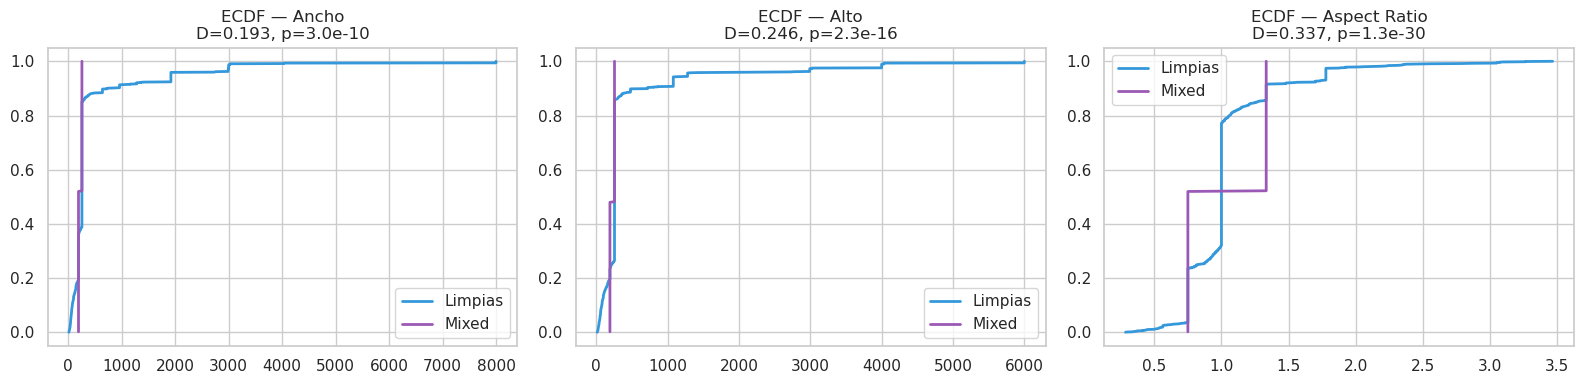

In [9]:
mixed=dim_df[dim_df.folder=='Mixed']; rest=dim_df[dim_df.folder!='Mixed']
print("H₀: Mixed proviene de la misma distribución espacial que las limpias\n")
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,(m,lab) in zip(ax,[('width','Ancho'),('height','Alto'),('aspect_ratio','Aspect Ratio')]):
    D,p=ks_2samp(mixed[m],rest[m])
    print(f"  {lab:13s} D_KS={D:.3f}  p={p:.2e}  {'→ DIFERENTE' if p<0.05 else '→ igual'}")
    for data,name,c in [(rest,'Limpias','#3498db'),(mixed,'Mixed','#9b59b6')]:
        sv=np.sort(data[m].values); a.plot(sv,np.arange(1,len(sv)+1)/len(sv),label=name,color=c,lw=2)
    a.set_title(f"ECDF — {lab}\nD={D:.3f}, p={p:.1e}"); a.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_discordancia_ks.pdf", bbox_inches="tight"); plt.show()

## 4. Propiedades visuales y resolución por clase

/tmp/ipykernel_1101402/1139211648.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sdf,x='quality',y=m,order=QUALITY_CLASSES,palette=QPAL,ax=a,width=.5); a.tick_params(axis='x',rotation=0)
/tmp/ipykernel_1101402/1139211648.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sdf,x='quality',y=m,order=QUALITY_CLASSES,palette=QPAL,ax=a,width=.5); a.tick_params(axis='x',rotation=0)
/tmp/ipykernel_1101402/1139211648.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sdf,x='quality',y=m,order=QUALITY_CLASSES,palette=QPAL,ax=a

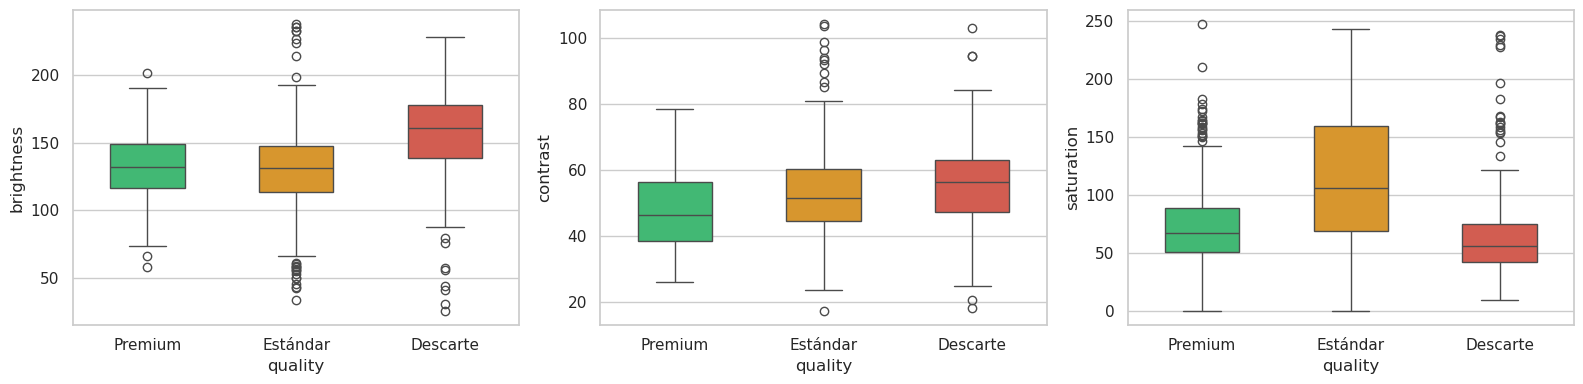

In [10]:
def vstats(path):
    im=cv2.imread(path)
    if im is None: return None
    g=cv2.cvtColor(im,cv2.COLOR_BGR2GRAY); s=cv2.cvtColor(im,cv2.COLOR_BGR2HSV)[:,:,1]
    h,w=im.shape[:2]
    return dict(width=w,height=h,aspect_ratio=w/h,brightness=float(g.mean()),contrast=float(g.std()),saturation=float(s.mean()))
rows=[]
for q in QUALITY_CLASSES:
    for p in df[df.quality==q].sample(min(300,len(df[df.quality==q])),random_state=SEED)['path']:
        st=vstats(p)
        if st: st['quality']=q; rows.append(st)
sdf=pd.DataFrame(rows)
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,m in zip(ax,['brightness','contrast','saturation']):
    sns.boxplot(data=sdf,x='quality',y=m,order=QUALITY_CLASSES,palette=QPAL,ax=a,width=.5); a.tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_propiedades.pdf", bbox_inches="tight"); plt.show()

### 4.1 Distribución de resoluciones por clase

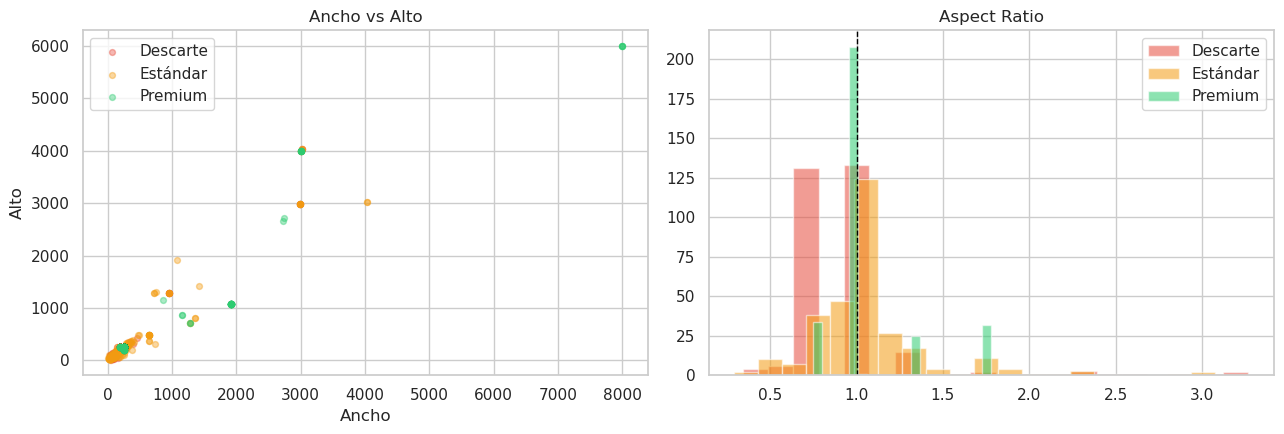

In [11]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
for q,g in sdf.groupby('quality'):
    ax[0].scatter(g.width,g.height,label=q,alpha=.4,s=18,color=QPAL[q])
ax[0].set_xlabel("Ancho"); ax[0].set_ylabel("Alto"); ax[0].set_title("Ancho vs Alto"); ax[0].legend()
for q,g in sdf.groupby('quality'):
    ax[1].hist(g.aspect_ratio,bins=20,alpha=.55,label=q,color=QPAL[q])
ax[1].axvline(1.0,color='black',ls='--',lw=1); ax[1].set_title("Aspect Ratio"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_resolucion.pdf", bbox_inches="tight"); plt.show()

## 5. Solapamiento distributivo Mixed vs clases limpias
Características de color (HSV-H,S) + textura (**LBP**), proyección **PCA**/**t-SNE**
y cuantificación con **Jensen–Shannon** y **Bhattacharyya**.

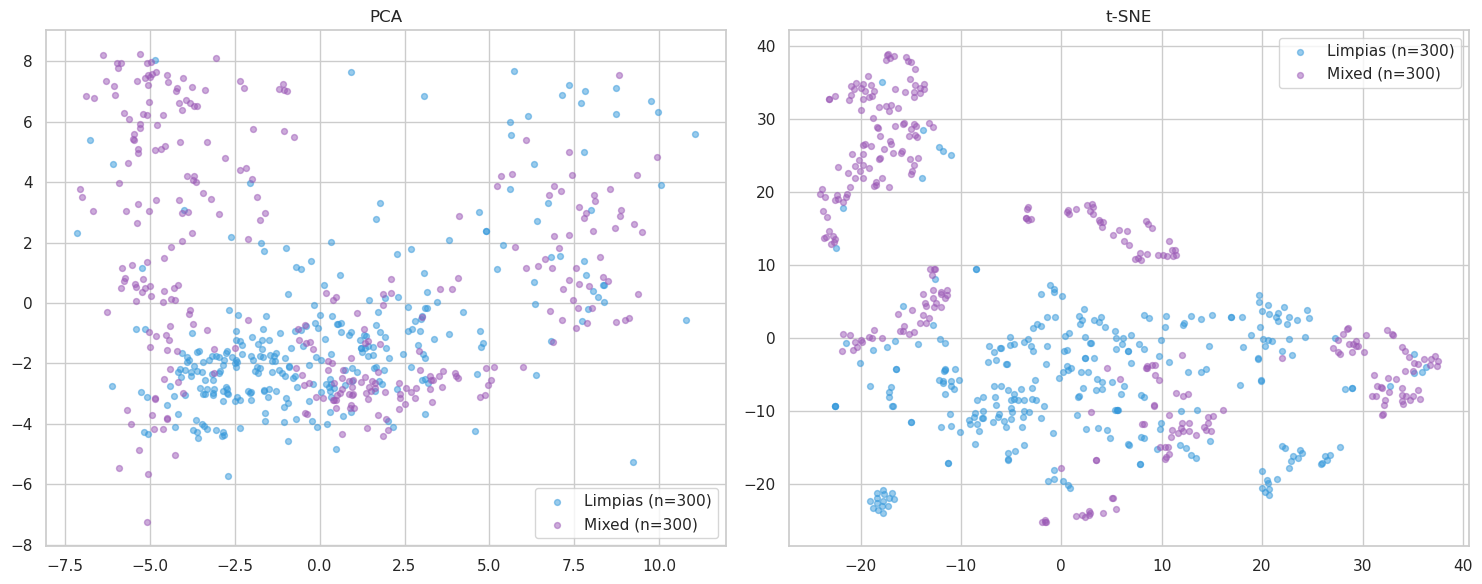

In [12]:
NB=32; R=3; P=8*R
def feat(path):
    im=cv2.imread(path)
    if im is None: return None
    im=cv2.resize(im,(128,128)); hsv=cv2.cvtColor(im,cv2.COLOR_BGR2HSV)
    hh=cv2.calcHist([hsv],[0],None,[NB],[0,180]).flatten(); hh/=hh.sum()+1e-8
    hs=cv2.calcHist([hsv],[1],None,[NB],[0,256]).flatten(); hs/=hs.sum()+1e-8
    lbp=local_binary_pattern(cv2.cvtColor(im,cv2.COLOR_BGR2GRAY),P,R,method='uniform')
    hl,_=np.histogram(lbp,bins=P+2,range=(0,P+2),density=True)
    return np.concatenate([hh,hs,hl])
groups={'Limpias':['Good','Regular','Bad'],'Mixed':['Mixed']}
X=[];lab=[]
for name,folders in groups.items():
    sub=df[df['folder'].isin(folders)]
    for p in sub.sample(min(300,len(sub)),random_state=SEED)['path']:
        f=feat(p)
        if f is not None: X.append(f); lab.append(name)
X=np.array(X); lab=np.array(lab)
Xs=StandardScaler().fit_transform(X)
pca=PCA(2,random_state=SEED).fit_transform(Xs)
tsne=TSNE(2,perplexity=30,init='pca',random_state=SEED).fit_transform(Xs)
fig,ax=plt.subplots(1,2,figsize=(15,6))
for emb,a,t in [(pca,ax[0],'PCA'),(tsne,ax[1],'t-SNE')]:
    for name,c in [('Limpias','#3498db'),('Mixed','#9b59b6')]:
        mk=lab==name; a.scatter(emb[mk,0],emb[mk,1],c=c,label=f"{name} (n={mk.sum()})",alpha=.5,s=18)
    a.set_title(t); a.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_solapamiento.pdf", bbox_inches="tight"); plt.show()

In [13]:
def jsd(p,q):
    p=p+1e-10;q=q+1e-10;m=.5*(p+q)
    return float(np.clip(.5*np.sum(p*np.log(p/m))+.5*np.sum(q*np.log(q/m)),0,1))
def bhatt(p,q): return float(np.sum(np.sqrt((p+1e-10)*(q+1e-10))))
pm=X[lab=='Mixed'].mean(0); pr=X[lab=='Limpias'].mean(0); pm/=pm.sum(); pr/=pr.sum()
print(f"Jensen–Shannon (Mixed ↔ Limpias): {jsd(pm,pr):.4f}   (0=idénticas, 1=disjuntas)")
print(f"Bhattacharyya  (Mixed ↔ Limpias): {bhatt(pm,pr):.4f}   (1=idénticas, 0=disjuntas)")
print("\n→ Mixed solapa fuertemente con las clases limpias en color/textura:")
print("  usarla como clase directa metería ruido de etiqueta. Por eso en Fase 3 se")
print("  segmenta en frutas individuales, se re-etiqueta por daño (NTC-4580) y va")
print("  SOLO a enriquecer train. La clase Estándar usa las carpetas Regular reales.")

Jensen–Shannon (Mixed ↔ Limpias): 0.0703   (0=idénticas, 1=disjuntas)
Bhattacharyya  (Mixed ↔ Limpias): 0.9257   (1=idénticas, 0=disjuntas)

→ Mixed solapa fuertemente con las clases limpias en color/textura:
  usarla como clase directa metería ruido de etiqueta. Por eso en Fase 3 se
  segmenta en frutas individuales, se re-etiqueta por daño (NTC-4580) y va
  SOLO a enriquecer train. La clase Estándar usa las carpetas Regular reales.


## 6. Espacio de color RGB — histograma promedio por clase

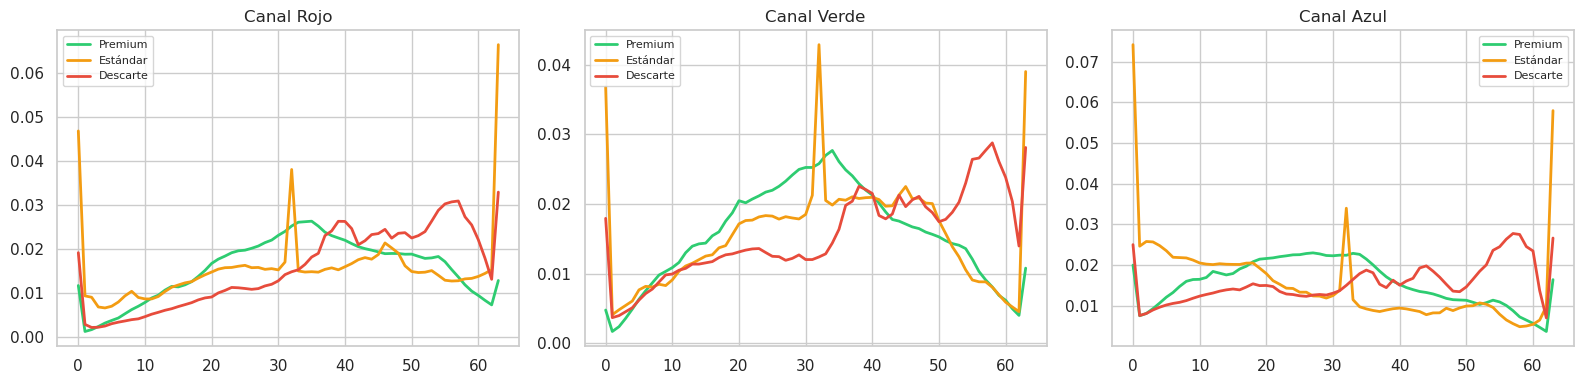

In [14]:
def rgb_hist(path,nb=64):
    im=cv2.imread(path)
    if im is None: return None
    im=cv2.cvtColor(im,cv2.COLOR_BGR2RGB); hs=[]
    for ch in range(3):
        h=cv2.calcHist([im],[ch],None,[nb],[0,256]).flatten(); h/=h.sum()+1e-8; hs.append(h)
    return np.array(hs)
fig,ax=plt.subplots(1,3,figsize=(16,4)); chan=['Rojo','Verde','Azul']; cc_=['r','g','b']
for q in QUALITY_CLASSES:
    hh=[rgb_hist(p) for p in df[df.quality==q].sample(min(100,len(df[df.quality==q])),random_state=SEED)['path']]
    hh=np.mean([h for h in hh if h is not None],axis=0)
    for ci in range(3):
        ax[ci].plot(hh[ci],label=q,color=QPAL[q],lw=2)
for ci in range(3): ax[ci].set_title(f"Canal {chan[ci]}"); ax[ci].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase2_rgb.pdf", bbox_inches="tight"); plt.show()

## 7. Tests estadísticos de diferencias entre clases (Kruskal–Wallis)

In [15]:
print("H₀: las 3 clases tienen la misma distribución de la propiedad\n")
for m in ['brightness','contrast','saturation']:
    H,p=kruskal(*[sdf[sdf.quality==q][m] for q in QUALITY_CLASSES])
    print(f"  {m:11s} H={H:7.2f}  p={p:.2e}  {'✓ SIGNIFICATIVO' if p<0.05 else '✗ no significativo'}")
print("\np<0.05 → diferencias reales entre clases → hay señal discriminante (justifica features de color en Fase 4).")

H₀: las 3 clases tienen la misma distribución de la propiedad

  brightness  H= 143.66  p=6.39e-32  ✓ SIGNIFICATIVO
  contrast    H=  70.62  p=4.62e-16  ✓ SIGNIFICATIVO
  saturation  H= 153.95  p=3.72e-34  ✓ SIGNIFICATIVO

p<0.05 → diferencias reales entre clases → hay señal discriminante (justifica features de color en Fase 4).


## 8. Comparación propio vs Kaggle (Mann–Whitney U)

In [16]:
rows=[]
for src in ['Kaggle','Propio']:
    sub=df[(df.source==src)&(df.quality!='Mixed')]
    for p in sub.sample(min(300,len(sub)),random_state=SEED)['path']:
        st=vstats(p)
        if st: st['source']=src; rows.append(st)
cmp=pd.DataFrame(rows)
print("Mann–Whitney U (Kaggle vs Propio):")
for m in ['brightness','contrast','saturation']:
    U,p=mannwhitneyu(cmp[cmp.source=='Kaggle'][m],cmp[cmp.source=='Propio'][m])
    print(f"  {m:11s} p={p:.2e}  {'→ DIFERENTE (domain shift)' if p<0.05 else '→ similar'}")
print("\n→ Si difieren, hay domain shift → en Fase 5 evaluamos el desempeño por fuente.")

Mann–Whitney U (Kaggle vs Propio):
  brightness  p=6.10e-18  → DIFERENTE (domain shift)
  contrast    p=9.20e-03  → DIFERENTE (domain shift)
  saturation  p=8.40e-27  → DIFERENTE (domain shift)

→ Si difieren, hay domain shift → en Fase 5 evaluamos el desempeño por fuente.


## 9. Resumen ejecutivo del EDA

In [17]:
print('═'*64)
print('  RESUMEN EJECUTIVO — EDA FruitVision (CRISP-DM Fase 2)')
print('═'*64)
print(f'''
1. ESCALA
   Total imágenes  : {len(df):,}  (Kaggle {(df.source=='Kaggle').sum():,} + Propio {(df.source=='Propio').sum():,})
   Frutas          : {df.fruit.nunique()}   Clases entrenamiento: 3 (+ Mixed aparte)

2. DESBALANCEO
   Premium {cc['Premium']:,} | Estándar {cc['Estándar']:,} | Descarte {cc['Descarte']:,}
   Imbalance Ratio : {ir:.2f}x  → cap por fruta×clase + class_weight (Fase 3)

3. MIXED (multi-fruta)
   Espacialmente DISTINTA (KS p≪0.05) y con alto solapamiento de color (Bhatt~0.9)
   → no es clase directa; se segmenta + re-etiqueta por daño (Fase 3, solo train)

4. SEÑAL DISCRIMINANTE
   Brillo/contraste/saturación difieren entre clases (Kruskal–Wallis p≪0.05)

5. DOMAIN SHIFT
   Propio vs Kaggle difieren (Mann–Whitney) → evaluación por fuente en Fase 5
''')

════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — EDA FruitVision (CRISP-DM Fase 2)
════════════════════════════════════════════════════════════════

1. ESCALA
   Total imágenes  : 26,385  (Kaggle 19,526 + Propio 6,859)
   Frutas          : 7   Clases entrenamiento: 3 (+ Mixed aparte)

2. DESBALANCEO
   Premium 11,797 | Estándar 5,680 | Descarte 7,834
   Imbalance Ratio : 2.08x  → cap por fruta×clase + class_weight (Fase 3)

3. MIXED (multi-fruta)
   Espacialmente DISTINTA (KS p≪0.05) y con alto solapamiento de color (Bhatt~0.9)
   → no es clase directa; se segmenta + re-etiqueta por daño (Fase 3, solo train)

4. SEÑAL DISCRIMINANTE
   Brillo/contraste/saturación difieren entre clases (Kruskal–Wallis p≪0.05)

5. DOMAIN SHIFT
   Propio vs Kaggle difieren (Mann–Whitney) → evaluación por fuente en Fase 5



## 10. Conclusiones decisiones para Fase 3
- Dataset **combinado** (Kaggle + propio); **Estándar = carpetas Regular reales**.
- **Cap por fruta×calidad** (corrige Pomegranate) + `class_weight`.
- **Split agrupado anti-fuga** (perceptual hash) — evita casi-duplicados entre splits.
- **Mixed**: segmentación individual + re-etiquetado por daño (NTC-4580), solo a train.
- **Tamaño** por segmentación (diámetro normalizado, terciles en train).